#  **Heart Disease Prediction Using Machine Learning Techniques**

---

##  **Introduction**

Heart disease is one of the leading causes of death worldwide. Early detection and diagnosis play a crucial role in reducing mortality rates and improving patient outcomes. With the advancement of machine learning, it has become possible to analyze medical data efficiently and predict the likelihood of heart disease.

This project aims to develop a machine learning model that can predict whether a patient is at risk of heart disease based on various medical attributes such as age, gender, pulse rate, glucose level, troponin, and other clinical features.

Various machine learning algorithms, including Logistic Regression, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), Naive Bayes, Decision Tree, and Random Forest, are applied and compared to determine the most effective model for accurate prediction.

Feature engineering and data preprocessing techniques such as handling outliers, log transformation, and feature selection are also implemented to enhance model performance.

---

<h2 style="font-weight:bold;">TOOLS AND LIBRARIES USED</h2>

<p style="font-size:16px;">
Various Python libraries are used for data analysis, preprocessing, visualization, and model building.
</p>

<ul style="font-size:16px;">
<li><b>Pandas</b> and <b>NumPy</b> are used for data manipulation and numerical operations.</li>
<li><b>Matplotlib</b> and <b>Seaborn</b> are used for data visualization.</li>
<li><b>Scikit-learn</b> is used for preprocessing, model building, and evaluation.</li>
</ul>

<p style="font-size:16px;">
Different classification algorithms such as Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Naive Bayes, Decision Tree, and Random Forest are used to build and compare models. Evaluation techniques like cross-validation and performance metrics are used to assess model accuracy.
</p>

In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn import metrics

<h2 style="font-weight:bold;">2.LOADING THE DATASET</h2>

In [77]:
df = pd.read_csv(r"C:\Users\user\Downloads\Heart Attack.csv")
print(df.head(8))

   age  gender  impluse  pressurehight  pressurelow  glucose     kcm  \
0   64       1       66            160           83    160.0    1.80   
1   21       1       94             98           46    296.0    6.75   
2   55       1       64            160           77    270.0    1.99   
3   64       1       70            120           55    270.0   13.87   
4   55       1       64            112           65    300.0    1.08   
5   58       0       61            112           58     87.0    1.83   
6   32       0       40            179           68    102.0    0.71   
7   63       1       60            214           82     87.0  300.00   

   troponin     class  
0     0.012  negative  
1     1.060  positive  
2     0.003  negative  
3     0.122  positive  
4     0.003  negative  
5     0.004  negative  
6     0.003  negative  
7     2.370  positive  


<h2 style="font-weight:bold;">3.DATA UNDERSTANDING</h2>

<p style="font-size:16px;">
In this step, we explore the structure and basic information of the dataset to understand its features, data types, and overall composition.
</p>

In [29]:
df.shape

(1319, 9)

In [30]:
df.columns

Index(['age', 'gender', 'impluse', 'pressurehight', 'pressurelow', 'glucose',
       'kcm', 'troponin', 'class'],
      dtype='object')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [32]:
df.describe()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


<h2 style="font-weight:bold;">DATA CLEANING</h2>

<p style="font-size:16px;">
Data cleaning is performed to ensure the quality and reliability of the dataset. Missing values, duplicate entries, and inconsistent data are checked and handled appropriately.
</p>

<p style="font-size:16px;">
This step helps in improving the accuracy and performance of the classification models by providing clean and well-structured data.
</p>

In [33]:
df.isnull().sum()

age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [79]:
df = df.rename(columns={'impluse':'pulse','pressurehight':'pressure_high','pressurelow':'pressure_low'  })
print(df.head(5))

   age  gender  pulse  pressure_high  pressure_low  glucose    kcm  troponin  \
0   64       1     66            160            83    160.0   1.80     0.012   
1   21       1     94             98            46    296.0   6.75     1.060   
2   55       1     64            160            77    270.0   1.99     0.003   
3   64       1     70            120            55    270.0  13.87     0.122   
4   55       1     64            112            65    300.0   1.08     0.003   

      class  
0  negative  
1  positive  
2  negative  
3  positive  
4  negative  


<h2 style="font-weight:bold;">5. EXPLORATORY DATA ANALYSIS (EDA)</h2>

<p style="font-size:16px;">
In this step, we analyze the dataset using summary statistics and visualizations like histograms, boxplots, and scatterplots. EDA helps identify patterns, trends, missing values, and potential outliers.
</p>



Question1: How many "positive" vs. "negative" heart attack cases are there?

class
positive    61.410159
negative    38.589841
Name: proportion, dtype: float64


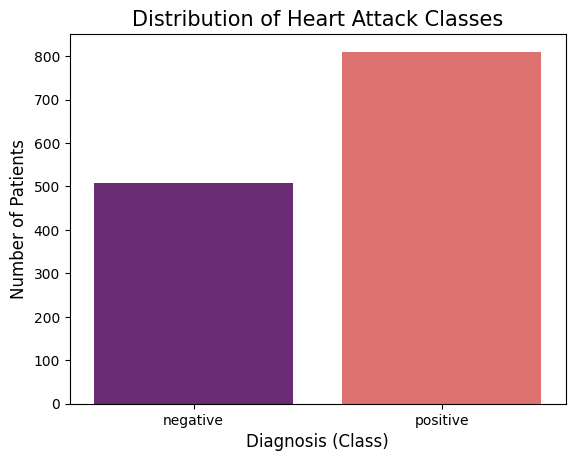

In [36]:
x = df['class'].value_counts(normalize=True) * 100
print(x)
plt.Figure(figsize=(8,5))
sns.countplot(x='class',data = df,palette='magma',hue='class',legend=False)
plt.title('Distribution of Heart Attack Classes', fontsize=15)
plt.xlabel('Diagnosis (Class)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

plt.show()


The plot shows that positive cases are higher than negative cases, indicating a slight class imbalance, which may affect model performance.

Question2 :  What is the age distribution of the patients?

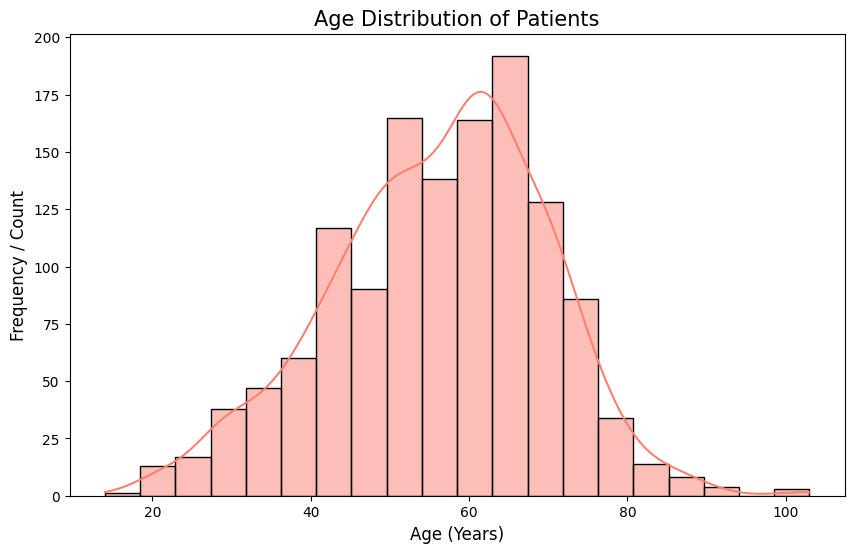

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'],kde=True,color='salmon',bins=20)
plt.title('Age Distribution of Patients', fontsize=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Frequency / Count', fontsize=12)

plt.show()

The plot shows that most patients are in the middle to older age group (around 50–70 years), with fewer younger and very old individuals. The distribution is slightly right-skewed, indicating that heart-related cases are more common in older patients.

Question3: Does Gender play a role in heart attack frequency?

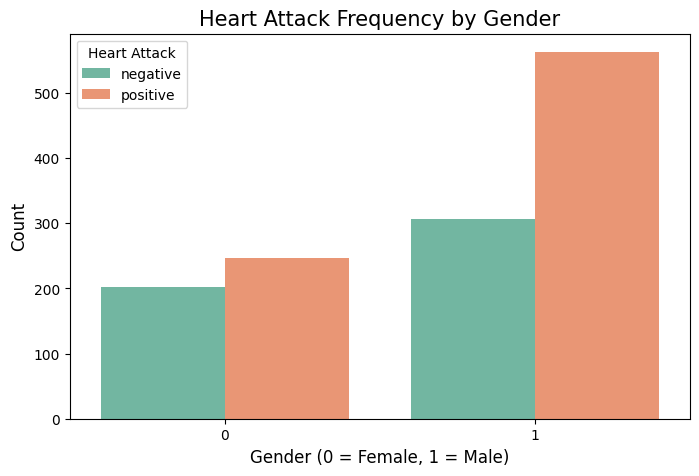

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x='gender',hue='class',data=df,palette='Set2')
plt.title('Heart Attack Frequency by Gender',fontsize=15)
plt.xlabel('Gender (0 = Female, 1 = Male)',fontsize = 12)
plt.ylabel('Count',fontsize=12)
plt.legend(title='Heart Attack')
plt.show()

The plot shows that male patients (1) have a higher number of heart attack (positive) cases compared to females (0). Overall, males appear to be more prone to heart attacks in this dataset.

Question4: Which feature (Troponin, Glucose, KCM) shows the biggest difference between sick and healthy patients?

          troponin     glucose        kcm
class                                    
negative  0.026988  149.757760   2.555344
positive  0.570798  144.671605  23.266838


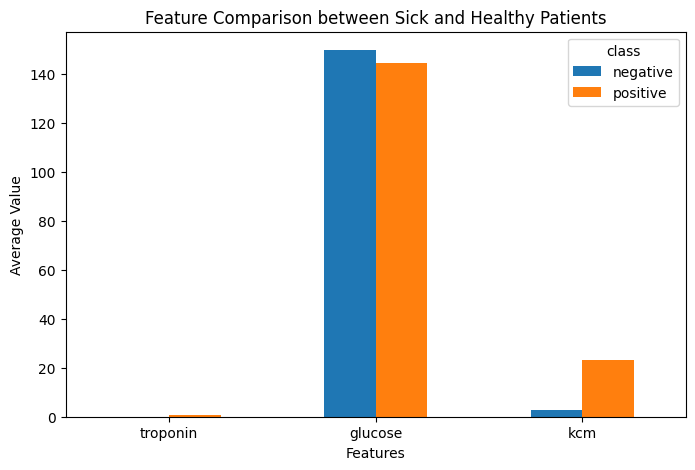

In [39]:
feature = ['troponin','glucose','kcm']
comparison = df.groupby('class')[feature].mean()
print(comparison)
comparison.T.plot(kind='bar', figsize=(8,5))
plt.title("Feature Comparison between Sick and Healthy Patients")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

The plot shows that troponin and KCM have a much higher average in positive (sick) patients compared to negative (healthy) patients, while glucose shows only a small difference.

Question5 :  Is there a correlation between Blood Pressure and Heart Attacks?

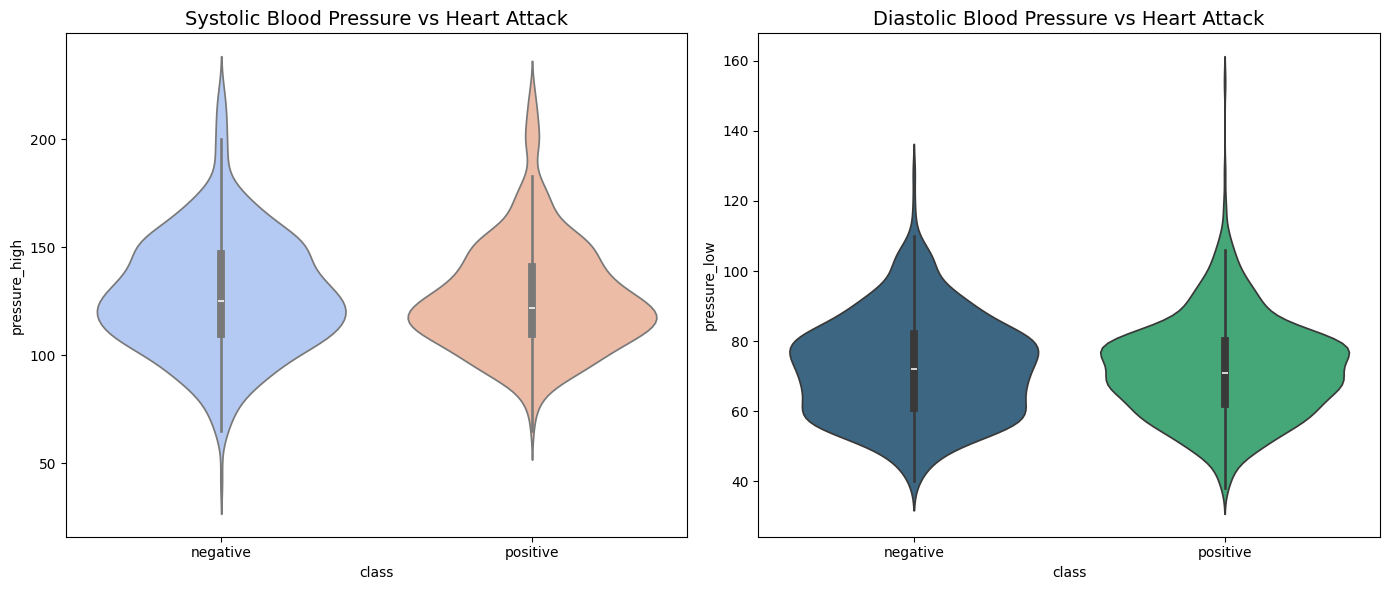

In [40]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.violinplot(x='class', y='pressure_high', data=df, palette='coolwarm',hue='class')
plt.title('Systolic Blood Pressure vs Heart Attack', fontsize=14)
plt.subplot(1, 2, 2)
sns.violinplot(x='class', y='pressure_low', data=df, palette='viridis',hue='class')
plt.title('Diastolic Blood Pressure vs Heart Attack', fontsize=14)

plt.tight_layout()
plt.show()

<p style="font-size:16px;">
The plots show that patients with positive cases tend to have slightly higher systolic and diastolic blood pressure compared to negative cases. However, there is significant overlap between the two groups, indicating a weak correlation between blood pressure and heart attacks.
</p>

Question6: Do heart attack patients have higher Troponin levels?

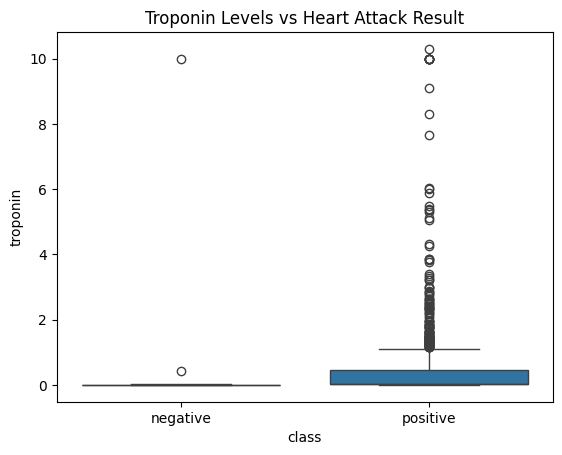

In [41]:
sns.boxplot(x='class', y='troponin', data=df)
plt.title("Troponin Levels vs Heart Attack Result")
plt.show()

Troponin levels are very low in negative cases and significantly higher in positive cases. The outliers in the positive group represent important clinical values, indicating that Troponin is a strong predictor of heart attacks.

Question7: How does Glucose vary with age?

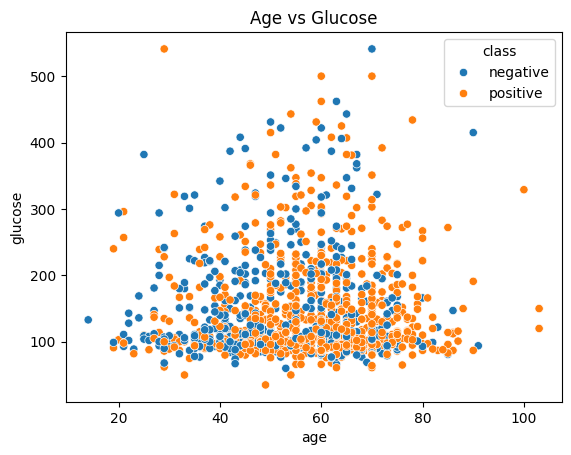

In [42]:
sns.scatterplot(x='age', y='glucose', hue='class', data=df)
plt.title("Age vs Glucose")
plt.show()

The scatter plot shows no strong relationship between age and glucose levels, as values are widely spread across all ages. Both positive and negative cases overlap significantly, indicating that glucose alone is not a strong predictor of heart attacks.

Question8: What is the distribution of Blood Pressure?

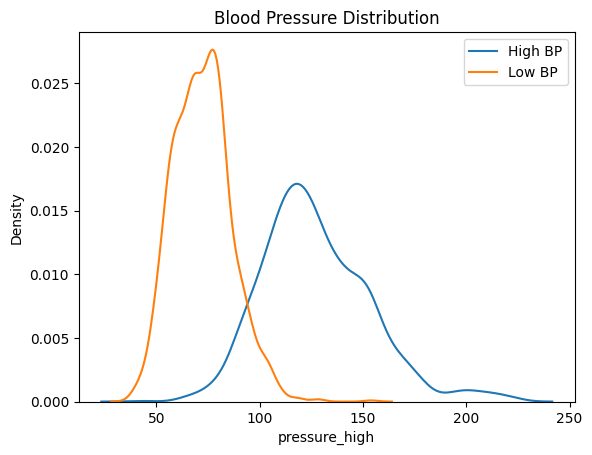

In [43]:
sns.kdeplot(df['pressure_high'], label='High BP')
sns.kdeplot(df['pressure_low'], label='Low BP')

plt.legend()
plt.title("Blood Pressure Distribution")
plt.show()

The distribution shows that systolic (high) blood pressure values are generally higher and more spread out compared to diastolic (low) pressure. Most values fall within a normal range, but a few extreme values indicate possible outliers or abnormal conditions.

Question9: Are multiple biomarkers (Troponin, KCM) jointly indicating heart attack?

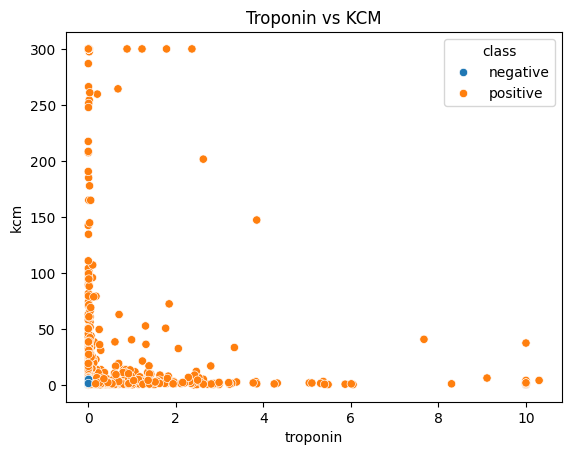

In [44]:
sns.scatterplot(x='troponin', y='kcm', hue='class', data=df)
plt.title("Troponin vs KCM")
plt.show()

<p style="font-size:16px;">
The scatter plot shows that patients with positive cases generally have higher troponin values, along with some elevated kcm levels. Negative cases are mostly concentrated at lower values of both biomarkers. This indicates that troponin and kcm together provide useful information in identifying heart attack cases, although the relationship is not strictly linear.
</p>

Question10: Which features are most correlated overall?

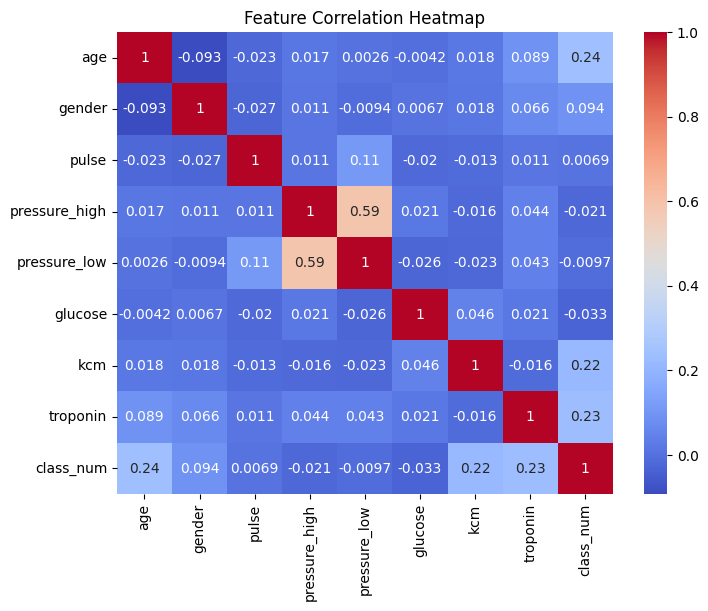

In [45]:
df['class_num'] = df['class'].map({'negative': 0, 'positive': 1})
correlation = df.corr(numeric_only=True)


plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation analysis shows that Troponin, Age, and KCM have the highest positive correlation with heart attack cases, making them important predictive features. Other variables such as pulse, blood pressure, and glucose show weak correlation with the target.

<h2 style="font-weight:bold;">DATA CLEANING</h2>

<p style="font-size:16px;">
Data cleaning was performed to handle outliers and improve the quality of the dataset. Different techniques were applied based on the nature of each feature.
</p>

<p style="font-size:16px;">
The pulse feature contained extreme values, which were handled by replacing high outliers with the median and applying clipping between 40 and 130 to maintain realistic medical ranges.
</p>

<p style="font-size:16px;">
Outliers in the kcm feature were treated using the Interquartile Range (IQR) method, where extreme values were capped to reduce their impact without removing data points.
</p>

<p style="font-size:16px;">
The troponin feature showed high skewness, so a logarithmic transformation (log1p) was applied to normalize its distribution.
</p>

<p style="font-size:16px;">
The glucose feature was handled using clipping between 40 and 300 to eliminate extreme values while preserving meaningful observations.
</p>

In [80]:
median_pulse = df.loc[df['pulse'] <= 200, 'pulse'].median()
df.loc[df['pulse'] > 200, 'pulse'] = median_pulse
df['pulse'].max()

np.int64(135)

In [81]:
Q1 = df['kcm'].quantile(0.25)
Q3 = df['kcm'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5*IQR
df['kcm'] = df['kcm'].clip(upper=upper)

In [82]:
df['troponin'] = np.log1p(df['troponin'])

In [83]:
df['pulse'] = df['pulse'].clip(40, 130)

df['glucose'] = df['glucose'].clip(40, 300)

The pulse and glucose features contained unrealistic and extreme values. These were capped within medically reasonable ranges using clipping to reduce the impact of outliers and improve model stability without removing data

<h2 style="font-weight:bold;">FEATURE ENGINEERING</h2>

<p style="font-size:16px;">
Feature engineering was performed to create new meaningful variables from existing data. A new feature called pulse pressure was derived by calculating the difference between systolic (pressure_high) and diastolic (pressure_low) blood pressure.
</p>

<p style="font-size:16px;">
This feature provides additional insight into cardiovascular health and may improve the performance of the classification model. The original features were retained along with the new feature to preserve all relevant information.
</p>

In [84]:
df['pulse_pressure'] = df['pressure_high'] - df['pressure_low']

In [85]:
print(df.head(6))

   age  gender  pulse  pressure_high  pressure_low  glucose    kcm  troponin  \
0   64       1     66            160            83    160.0   1.80  0.011929   
1   21       1     94             98            46    296.0   6.75  0.722706   
2   55       1     64            160            77    270.0   1.99  0.002996   
3   64       1     70            120            55    270.0  12.03  0.115113   
4   55       1     64            112            65    300.0   1.08  0.002996   
5   58       0     61            112            58     87.0   1.83  0.003992   

      class  pulse_pressure  
0  negative              77  
1  positive              52  
2  negative              83  
3  positive              65  
4  negative              47  
5  negative              54  


In [86]:
df.describe()

,age,gender,pulse,pressure_high,pressure_low,glucose,kcm,troponin,pulse_pressure
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,75.986353,127.170584,72.269143,142.729871,4.463456,0.181798,54.901440
std,13.647315,0.474027,15.067570,26.122720,14.033924,62.796063,3.825702,0.400924,21.202957
min,14.000000,0.000000,40.000000,42.000000,38.000000,40.000000,0.321000,0.001000,-78.000000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.005982,42.000000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.013903,52.000000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.082041,65.000000
max,103.000000,1.000000,130.000000,223.000000,154.000000,300.000000,12.030000,2.424803,168.000000


In [87]:
df = df[df['pulse_pressure'] > 0]

In [88]:
df = df.reset_index(drop=True)

In [89]:
df['pulse_pressure'].min()

np.int64(12)

In [90]:
df.describe()

,age,gender,pulse,pressure_high,pressure_low,glucose,kcm,troponin,pulse_pressure
count,1308.000000,1308.000000,1308.000000,1308.00000,1308.000000,1308.000000,1308.000000,1308.000000,1308.000000
mean,56.196483,0.661315,75.971713,127.64526,72.131498,142.921789,4.470497,0.182940,55.513761
std,13.685966,0.473444,15.081872,25.69394,13.864614,62.940334,3.830276,0.402309,20.118447
min,14.000000,0.000000,40.000000,65.00000,38.000000,40.000000,0.321000,0.001000,12.000000
25%,47.000000,0.000000,64.000000,110.00000,61.750000,98.000000,1.660000,0.005982,42.000000
50%,58.000000,1.000000,74.000000,124.00000,72.000000,116.000000,2.850000,0.013903,52.000000
75%,65.000000,1.000000,85.000000,144.00000,81.000000,170.250000,5.812500,0.083651,66.000000
max,103.000000,1.000000,130.000000,223.00000,128.000000,300.000000,12.030000,2.424803,168.000000


<p style="font-size:16px;">
After removing invalid values, the pulse pressure feature was ensured to have only positive and physiologically meaningful values, improving data quality.
</p>

<h2 style="font-weight:bold;">DATA PREPROCESSING</h2>

<p style="font-size:16px;">
The target variable was converted into numerical form using label encoding. The class labels were transformed into binary values, where 0 represents negative and 1 represents positive cases.
</p>

In [91]:
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'negative': np.int64(0), 'positive': np.int64(1)}


In [92]:
print(df.head(5))

   age  gender  pulse  pressure_high  pressure_low  glucose    kcm  troponin  \
0   64       1     66            160            83    160.0   1.80  0.011929   
1   21       1     94             98            46    296.0   6.75  0.722706   
2   55       1     64            160            77    270.0   1.99  0.002996   
3   64       1     70            120            55    270.0  12.03  0.115113   
4   55       1     64            112            65    300.0   1.08  0.002996   

   class  pulse_pressure  
0      0              77  
1      1              52  
2      0              83  
3      1              65  
4      0              47  


<h2 style="font-weight:bold;">FEATURE SELECTION AND DATA SPLITTING</h2>

<p style="font-size:16px;">
The dataset was divided into input features and target variable. All independent variables such as age, gender, pulse, blood pressure, glucose, kcm, troponin, and pulse pressure were used as input features, while the class variable was selected as the target.
</p>

<p style="font-size:16px;">
The data was then split into training and testing sets using an 80:20 ratio. The training set was used to build the model, while the testing set was used to evaluate its performance.
</p>

In [95]:
x = df.drop('class', axis=1)
y = df['class']
print(x)
print(y)


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

      age  gender  pulse  pressure_high  pressure_low  glucose    kcm  \
0      64       1     66            160            83    160.0   1.80   
1      21       1     94             98            46    296.0   6.75   
2      55       1     64            160            77    270.0   1.99   
3      64       1     70            120            55    270.0  12.03   
4      55       1     64            112            65    300.0   1.08   
...   ...     ...    ...            ...           ...      ...    ...   
1303   44       1     94            122            67    204.0   1.63   
1304   66       1     84            125            55    149.0   1.33   
1305   45       1     85            168           104     96.0   1.24   
1306   54       1     58            117            68    300.0   5.80   
1307   51       1     94            157            79    134.0  12.03   

      troponin  pulse_pressure  
0     0.011929              77  
1     0.722706              52  
2     0.002996          

<h2 style="font-weight:bold;">FEATURE SCALING</h2>

<p style="font-size:16px;">
Feature scaling was performed using StandardScaler to standardize the range of independent variables. This technique transforms the data so that it has a mean of 0 and a standard deviation of 1.
</p>

<p style="font-size:16px;">
The scaler was fitted on the training data and then applied to both training and testing datasets to ensure consistency and avoid data leakage.
</p>

In [97]:
st_x = StandardScaler()
x_train_scaled = st_x.fit_transform(x_train)
x_test_scaled = st_x.transform(x_test)

<h2 style="font-weight:bold;">MODEL BUILDING AND EVALUATION</h2>

<p style="font-size:16px;">
In this stage, multiple machine learning classification models were trained using the preprocessed dataset. The models were evaluated on the test data to compare their performance and identify the most effective model for prediction.
</p>

<ul style="font-size:16px;">
  <li>Logistic Regression</li>
  <li>K-Nearest Neighbors (KNN)</li>
  <li>Support Vector Classifier (SVC)</li>
  <li>Naive Bayes</li>
  <li>Decision Tree</li>
  <li>Random Forest</li>
</ul>

<p style="font-size:16px;">
The performance of each model was assessed using evaluation metrics such as Accuracy, Precision, Recall, F1-Score,Confusion Matrix and classification report. These metrics help in determining the reliability and effectiveness of the models.
</p>

In [100]:
LG_MODEL = LogisticRegression()
LG_param_grid = [
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [0.1, 1, 10],
        'max_iter': [3000, 5000]
    },
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'C': [0.1, 1, 10],
        'max_iter': [3000, 5000]
    }
]

L_grid_search = GridSearchCV(LG_MODEL,LG_param_grid, cv=5)
L_grid_search.fit(x_train_scaled, y_train)
print("Best Parameters:", L_grid_search.best_params_)

L_best_model = L_grid_search.best_estimator_
y_pred = L_best_model.predict(x_test_scaled)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2

Best Parameters: {'C': 10, 'max_iter': 5000, 'penalty': 'l1', 'solver': 'liblinear'}


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [101]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test,y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test,y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print('Accuracy:',metrics.accuracy_score(y_test,y_pred) * 100,'%')
# Confusion matrix
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))

# Classification report
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))

Mean Absolute Error: 0.04580152671755725
Mean Squared Error: 0.04580152671755725
Root Mean Squared Error: 0.2140129125019265
Accuracy: 95.41984732824427 %
Confusion Matrix:
 [[ 90   5]
 [  7 160]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        95
           1       0.97      0.96      0.96       167

    accuracy                           0.95       262
   macro avg       0.95      0.95      0.95       262
weighted avg       0.95      0.95      0.95       262



In [102]:
knn = KNeighborsClassifier()
param_grid2 = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(knn, param_grid2, cv=5, scoring='accuracy')
grid_knn.fit(x_train_scaled, y_train)
print("Best Parameters:", grid_knn.best_params_)
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(x_test_scaled)


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [104]:
# Accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred_knn) * 100,'%')

# Confusion matrix
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred_knn))

# Classification report
print("Classification Report:\n", metrics.classification_report(y_test, y_pred_knn))

Accuracy: 77.09923664122137 %
Confusion Matrix:
 [[ 75  20]
 [ 40 127]]
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.79      0.71        95
           1       0.86      0.76      0.81       167

    accuracy                           0.77       262
   macro avg       0.76      0.77      0.76       262
weighted avg       0.79      0.77      0.77       262



In [105]:
classifier = SVC()
param_grid3 = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(classifier,param_grid3,cv=5)
grid_svm.fit(x_train_scaled, y_train)

print("Best Parameters:", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(x_test_scaled)

Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}


In [106]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred_svm) * 100,'%')
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred_svm))

Accuracy: 95.80152671755725 %
Confusion Matrix:
 [[ 91   4]
 [  7 160]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94        95
           1       0.98      0.96      0.97       167

    accuracy                           0.96       262
   macro avg       0.95      0.96      0.95       262
weighted avg       0.96      0.96      0.96       262



In [107]:
classifier1 = GaussianNB()
classifier1.fit(x_train_scaled,y_train)
y_prediction = classifier1.predict(x_test_scaled) 

In [111]:
accuracy = metrics.accuracy_score(y_test,y_prediction)
print('Accuracy: %.2f' % (accuracy*100))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test,y_prediction))
print("Classification Report:\n", metrics.classification_report(y_test, y_prediction))

Accuracy: 95.42
Confusion Matrix:
 [[ 94   1]
 [ 11 156]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94        95
           1       0.99      0.93      0.96       167

    accuracy                           0.95       262
   macro avg       0.94      0.96      0.95       262
weighted avg       0.96      0.95      0.95       262



In [110]:
Model = DecisionTreeClassifier()

param_grid4 = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search4 = GridSearchCV(Model, param_grid4, cv=5)
grid_search4.fit(x_train_scaled, y_train)

print("Best Parameters:", grid_search4.best_params_)

best_dt = grid_search4.best_estimator_
y_pred_dt = best_dt.predict(x_test_scaled)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [112]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred_dt) * 100,'%')
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test,y_pred_dt))
print("Classification Report:\n", metrics.classification_report(y_test,y_pred_dt))

Accuracy: 98.09160305343512 %
Confusion Matrix:
 [[ 92   3]
 [  2 165]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97        95
           1       0.98      0.99      0.99       167

    accuracy                           0.98       262
   macro avg       0.98      0.98      0.98       262
weighted avg       0.98      0.98      0.98       262



In [113]:
rf_model = RandomForestClassifier()

param_grid5 = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search5 = GridSearchCV(rf_model, param_grid5, cv=5, n_jobs=-1)
grid_search5.fit(x_train_scaled, y_train)

print("Best Parameters:", grid_search5.best_params_)

best_rf = grid_search5.best_estimator_
y_pred_rf = best_rf.predict(x_test_scaled)

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [114]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred_rf) * 100,'%')
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred_rf))

Accuracy: 98.85496183206108 %
Confusion Matrix:
 [[ 94   1]
 [  2 165]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98        95
           1       0.99      0.99      0.99       167

    accuracy                           0.99       262
   macro avg       0.99      0.99      0.99       262
weighted avg       0.99      0.99      0.99       262



<h2 style="font-weight:bold;">CONCLUSION</h2>

<p style="font-size:16px;">
This project focused on analyzing and predicting heart attack cases using machine learning techniques. Various steps including data cleaning, feature engineering, and exploratory data analysis were performed to improve data quality and extract meaningful insights.
</p>

<p style="font-size:16px;">
Multiple classification models such as Logistic Regression, K-Nearest Neighbors, Support Vector Classifier, Naive Bayes, Decision Tree, and Random Forest were implemented and evaluated using performance metrics like accuracy, precision, recall, and F1-score.
</p>

<p style="font-size:16px;">
Among all the models, the Random Forest classifier achieved the highest accuracy of 98.85% with minimal misclassification, making it the most reliable model for predicting heart attack cases.
</p>

<p style="font-size:16px;">
The results demonstrate that machine learning techniques can effectively assist in early detection and prediction of heart-related conditions, which can support better medical decision-making.
</p>

<h2 style="font-weight:bold;">PREDICTION</h2>

In [117]:
new_data = pd.DataFrame([[60, 1, 80, 140, 90, 150, 3.5, 0.05, 50]],
                        columns=['age', 'gender', 'pulse', 'pressure_high',
                                 'pressure_low', 'glucose', 'kcm', 'troponin',
                                 'pulse_pressure'])
new_data_scaled = st_x.transform(new_data)

prediction = best_rf.predict(new_data_scaled)

if prediction[0] == 1:
    print("Prediction: Positive (Heart Attack Risk)")
else:
    print("Prediction: Negative (No Heart Attack Risk)")

Prediction: Positive (Heart Attack Risk)




<p style="font-size:16px;">
The trained Random Forest model was used to predict heart attack risk for new patient data. The input features were provided in the same format as the training dataset and scaled using the previously fitted StandardScaler to ensure consistency.
</p>

<p style="font-size:16px;">
The model output was interpreted into a user-friendly format, where 0 represents negative and 1 represents positive cases. Based on the prediction, the model classifies whether a patient is at risk of a heart attack or not.
</p>

<p style="font-size:16px;">
For the given input, the model predicted a <strong>Positive (Heart Attack Risk)</strong>, indicating a high likelihood of heart-related issues.
</p>